Name:Wafa Karim Khan

Msc(Data science & Big Data Analytics)

College: B.K Birla College of Arts, Science and Commerce kalyan.

Task7:Image Classification with Convolutional Neural Networks.

Import necessary libraries and modules

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


Load and preprocess the CIFAR-10 dataset

In [4]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


Design and build the CNN architecture

In [5]:
model = Sequential() #This creates a new Sequential model

# Convolutional layers
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3))) #perform 2D convolution on the input
model.add(MaxPooling2D((2, 2))) 
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))

# Flatten layer
#This layer flattens the 3D feature maps into a 1D vector
model.add(Flatten())

# Fully connected layers
#Dense defines a fully connected layer with the specified number of neurons.

model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',  #measures the difference between predicted values and actual labels.
              metrics=['accuracy'])

#I am using the Adam optimizer and categorical cross-entropy loss function for multi-class classification.
#included accuracy as a metric to monitor during training.




C:\Users\tauqu\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train the CNN on the dataset

In [5]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3235 - loss: 1.8154 - val_accuracy: 0.5443 - val_loss: 1.2778
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5557 - loss: 1.2378 - val_accuracy: 0.6121 - val_loss: 1.0988
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6217 - loss: 1.0787 - val_accuracy: 0.6236 - val_loss: 1.0545
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6563 - loss: 0.9789 - val_accuracy: 0.6547 - val_loss: 0.9862
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6872 - loss: 0.9010 - val_accuracy: 0.6744 - val_loss: 0.9385
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7117 - loss: 0.8278 - val_accuracy: 0.6891 - val_loss: 0.8944
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7253 - loss: 0.7830 - val_accuracy: 0.6766 - val_loss: 0.9273
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7438 - loss: 0.7319 - val_accuracy:

Evaluate the model's performance

In [6]:
test_loss, test_accuracy = model.evaluate(X_test, y_test) #It returns the test loss and test accuracy
print(f'Test loss: {test_loss}') #This value represents the average loss.
print(f'Test accuracy: {test_accuracy}') #This value represents the proportion of correctly classified samples in test dataset. 


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7171 - loss: 0.8541
Test loss: 0.8615798950195312
Test accuracy: 0.7125999927520752


Visualize the training history

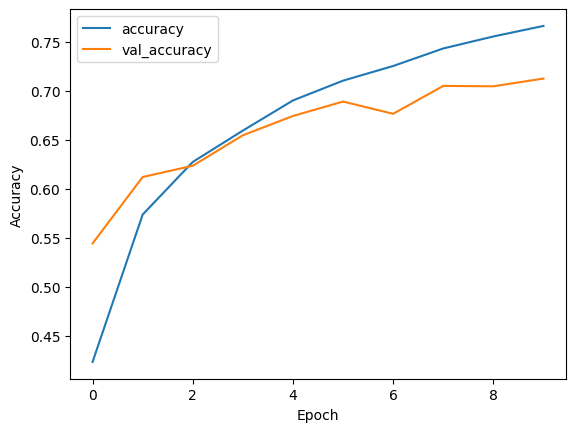

In [7]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


Observations:
1.The training accuracy appears to be plateauing or starting to decrease after about 6 epochs. This suggests that the model may be starting to overfit the training data.
    
2.The validation accuracy appears to be increasing over time, which is a good sign. This suggests that the model is still learning and improving its ability to generalize to unseen data.